# Тайвань — КНР: разбор кейса

**Данные:** GDELT 1.0 Event Export, пара КНР — Тайвань, окно **05.06.2022 — 03.08.2022**
(60 дней), 11 203 события.

**Это отрицательный кейс: войны не последовало.** 2–3 августа состоялся визит спикера Палаты
представителей США на Тайвань, 4 августа КНР начала масштабные учения с боевыми стрельбами —
но военного конфликта между сторонами не произошло. Именно поэтому кейс и ценен: во всей серии
это единственный материал, на котором можно оценивать **ложные тревоги**, а не только
чувствительность.

Разбор построен так же, как для положительных кейсов, но читать его нужно наоборот: здесь
«успех» индикатора — это **молчание**.

**Тип кейса:** отрицательный.

---

### Структура отчёта

1. Загрузка и первичная проверка
2. EDA — разведочный анализ
3. Предобработка и метрики
4. Периоды и скользящие окна
5. Три гипотезы, поправка Бонферрони, проверка устойчивости
6. Визуализация
7. Правило TONE-1σ
8. Выводы

## 0. Настройка окружения

In [1]:
import warnings, re, os
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, DayLocator
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Палитра (валидированная, CVD-safe; светлая поверхность) -------------------
SURFACE   = "#fcfcfb"   # поверхность графика
INK       = "#0b0b0b"   # основной текст
INK_2     = "#52514e"   # вторичный текст
MUTED     = "#898781"   # подписи осей
GRID      = "#e1e0d9"   # сетка
AXIS      = "#c3c2b7"   # оси
BLUE      = "#2a78d6"   # серия 1
ORANGE    = "#eb6834"   # серия 2
AQUA      = "#1baf7a"   # серия 3
CRITICAL  = "#d03b3b"   # статус: критично
GOOD      = "#0ca30c"   # статус: норма
SEQ_BLUE  = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
# Расходящаяся шкала: синий <-> красный, нейтральный серый в середине
DIVERGING = LinearSegmentedColormap.from_list(
    "div_blue_red",
    ["#104281", "#2a78d6", "#9ec5f4", "#f0efec", "#efa9a8", "#d03b3b", "#8f2020"],
)
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.titlepad": 26, "axes.labelsize": 10.5, "axes.labelcolor": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.grid": True, "axes.grid.axis": "y",
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_2,
    "lines.linewidth": 2.0, "lines.markersize": 5.5,
})

def subtitle(ax, text):
    # Подзаголовок под заголовком графика
    ax.annotate(text, xy=(0, 1.012), xycoords="axes fraction",
                fontsize=9.5, color=MUTED, ha="left", va="bottom")


print("Окружение готово.")

Окружение готово.


---
## 1. Загрузка и первичная проверка

In [2]:
CASE_NAME = "Тайвань — КНР"
CSV_PATH  = "data/taiwan_prc.csv"
DAY_X     = "2022-08-04"          # день военной акции; в расчётах не участвует
EVENT     = "учения НОАК с боевыми стрельбами"
PAIR_GEO  = ['TW', 'CH']              # коды FIPS территорий обеих стран пары

raw = pd.read_csv(CSV_PATH, encoding="utf-8", low_memory=False, dtype=str)
n_hdr = int((raw.DATEADDED == "DATEADDED").sum()); raw = raw[raw.DATEADDED != "DATEADDED"]
n_dup = int(raw.GLOBALEVENTID.duplicated().sum()); raw = raw.drop_duplicates(subset="GLOBALEVENTID")
for c in ["GoldsteinScale", "AvgTone", "NumArticles", "NumMentions", "NumSources",
          "EventRootCode", "EventCode", "QuadClass", "IsRootEvent"]:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")
raw["date_added"] = pd.to_datetime(raw.DATEADDED, format="%Y%m%d")
raw["sql_date"]   = pd.to_datetime(raw.SQLDATE,   format="%Y%m%d")

DAY_X = pd.Timestamp(DAY_X)
df = raw[raw.date_added < DAY_X].copy()
SPLIT = DAY_X - pd.Timedelta(days=7)      # последние 7 дней — «поздний период»

print(f"КЕЙС: {CASE_NAME} | день X: {DAY_X.date()} ({EVENT})")
print(f"Размерность: {df.shape[0]:,} строк × {df.shape[1]} колонок")
print(f"Окно: {df.date_added.min().date()} — {df.date_added.max().date()}")
full = pd.date_range(df.date_added.min(), df.date_added.max())
have = pd.DatetimeIndex(sorted(df.date_added.unique()))
print(f"Дней с данными: {len(have)} из {len(full)} календарных")
miss = full.difference(have)
print(f"Пропущенные дни: {'нет' if len(miss) == 0 else list(miss.date)}")
print(f"Повторных строк-заголовков удалено: {n_hdr} | дубликатов GLOBALEVENTID: {n_dup}")
print(f"Уникальных статей: {df.SOURCEURL.nunique():,} "
      f"({len(df)/df.SOURCEURL.nunique():.2f} строки на статью)")
lag = (df.date_added - df.sql_date).dt.days
print(f"Лаг DATEADDED − SQLDATE: медиана {int(lag.median())} дн., "
      f"90-й перцентиль {int(lag.quantile(0.9))} дн.")
print("\nПары акторов:")
print(df.groupby(["Actor1CountryCode", "Actor2CountryCode"]).size()
      .sort_values(ascending=False).head(3).to_string())

КЕЙС: Тайвань — КНР | день X: 2022-08-04 (учения НОАК с боевыми стрельбами)
Размерность: 11,203 строк × 60 колонок
Окно: 2022-06-05 — 2022-08-03
Дней с данными: 60 из 60 календарных
Пропущенные дни: нет
Повторных строк-заголовков удалено: 0 | дубликатов GLOBALEVENTID: 0
Уникальных статей: 3,860 (2.90 строки на статью)
Лаг DATEADDED − SQLDATE: медиана 0 дн., 90-й перцентиль 0 дн.

Пары акторов:
Actor1CountryCode  Actor2CountryCode
CHN                TWN                  6694
TWN                CHN                  4509


**Вывод по разделу 1.** 11 203 события за 60 дней без пропусков, 3 860 статей, 2,90 строки на
статью. По объёму это второй кейс серии после США — Иран: медиана 92 события в день. Данные
чистые — ни дубликатов, ни повторных заголовков.

---
## 2. EDA — разведочный анализ

### 2.1 Пропуски по колонкам

In [3]:
na = pd.DataFrame({"n_missing": df.isna().sum(),
                   "pct_missing": (df.isna().mean()*100).round(1)}).sort_values("n_missing", ascending=False)
display(na[na.n_missing > 0].head(16))
print("Колонок без пропусков:", int((na.n_missing == 0).sum()), "из", df.shape[1])
print("\nКлючевые колонки:")
for c in ["DATEADDED", "GoldsteinScale", "AvgTone", "NumArticles", "EventRootCode", "EventCode",
          "QuadClass", "IsRootEvent", "ActionGeo_CountryCode", "SOURCEURL"]:
    print(f"  {c:<22} пропусков: {int(df[c].isna().sum())}")

,n_missing,pct_missing
Actor1KnownGroupCode,11203,100.0000
Actor1EthnicCode,11203,100.0000
Actor1Religion1Code,11203,100.0000
Actor1Religion2Code,11203,100.0000
Actor2Religion1Code,11203,100.0000
Actor2KnownGroupCode,11203,100.0000
Actor2Type3Code,11203,100.0000
Actor2Religion2Code,11203,100.0000
Actor2EthnicCode,11203,100.0000
Actor1Type3Code,11203,100.0000


Колонок без пропусков: 28 из 60

Ключевые колонки:
  DATEADDED              пропусков: 0
  GoldsteinScale         пропусков: 0
  AvgTone                пропусков: 0
  NumArticles            пропусков: 0
  EventRootCode          пропусков: 0
  EventCode              пропусков: 0
  QuadClass              пропусков: 0
  IsRootEvent            пропусков: 0
  ActionGeo_CountryCode  пропусков: 1
  SOURCEURL              пропусков: 0


### 2.2 Поток событий по дням

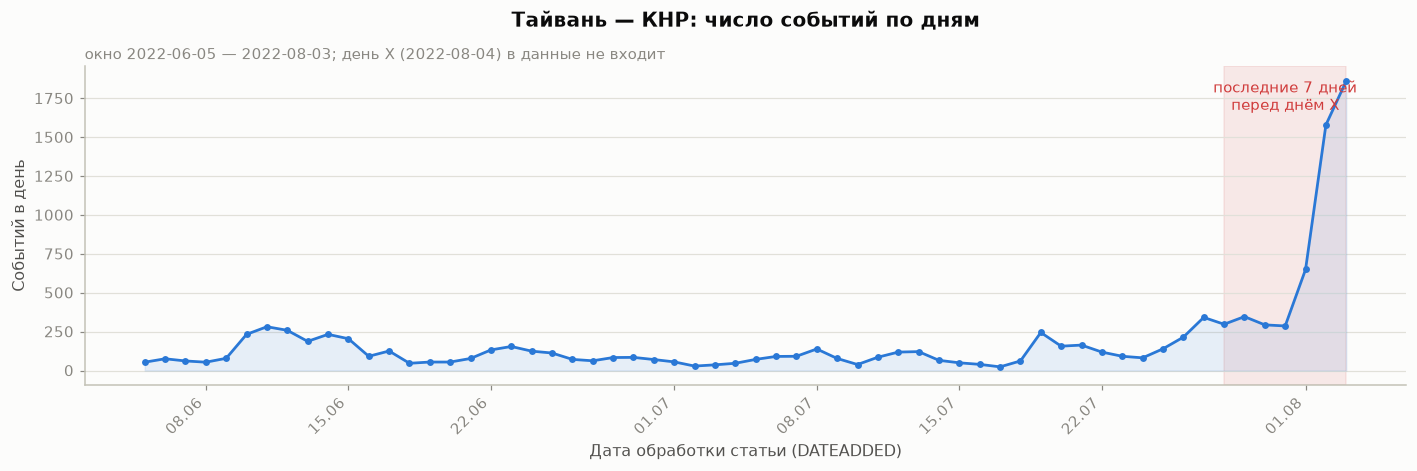

событий/день — медиана 92, мин 24, макс 1863 (2022-08-03)
последние 7 дней — медиана 347


In [4]:
by_day = df.groupby("date_added").size().rename("events")

fig, ax = plt.subplots(figsize=(13, 4.4))
ax.plot(by_day.index, by_day.values, color=BLUE, lw=1.8, marker="o", markersize=3.5, zorder=3)
ax.fill_between(by_day.index, by_day.values, color=BLUE, alpha=0.10, zorder=2)
ax.axvspan(SPLIT, by_day.index.max(), color=CRITICAL, alpha=0.10, zorder=1)
ax.annotate("последние 7 дней\nперед днём X", xy=(SPLIT + pd.Timedelta(days=3), by_day.max()*0.9),
            color=CRITICAL, fontsize=9.5, ha="center")
ax.set_title(f"{CASE_NAME}: число событий по дням")
subtitle(ax, f"окно {by_day.index.min().date()} — {by_day.index.max().date()}; "
             f"день X ({DAY_X.date()}) в данные не входит")
ax.set_xlabel("Дата обработки статьи (DATEADDED)"); ax.set_ylabel("Событий в день")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print(f"событий/день — медиана {int(by_day.median())}, мин {int(by_day.min())}, "
      f"макс {int(by_day.max())} ({by_day.idxmax().date()})")
print(f"последние 7 дней — медиана {int(by_day.tail(7).median())}")

### 2.3 Распределения, нормальность, выбросы

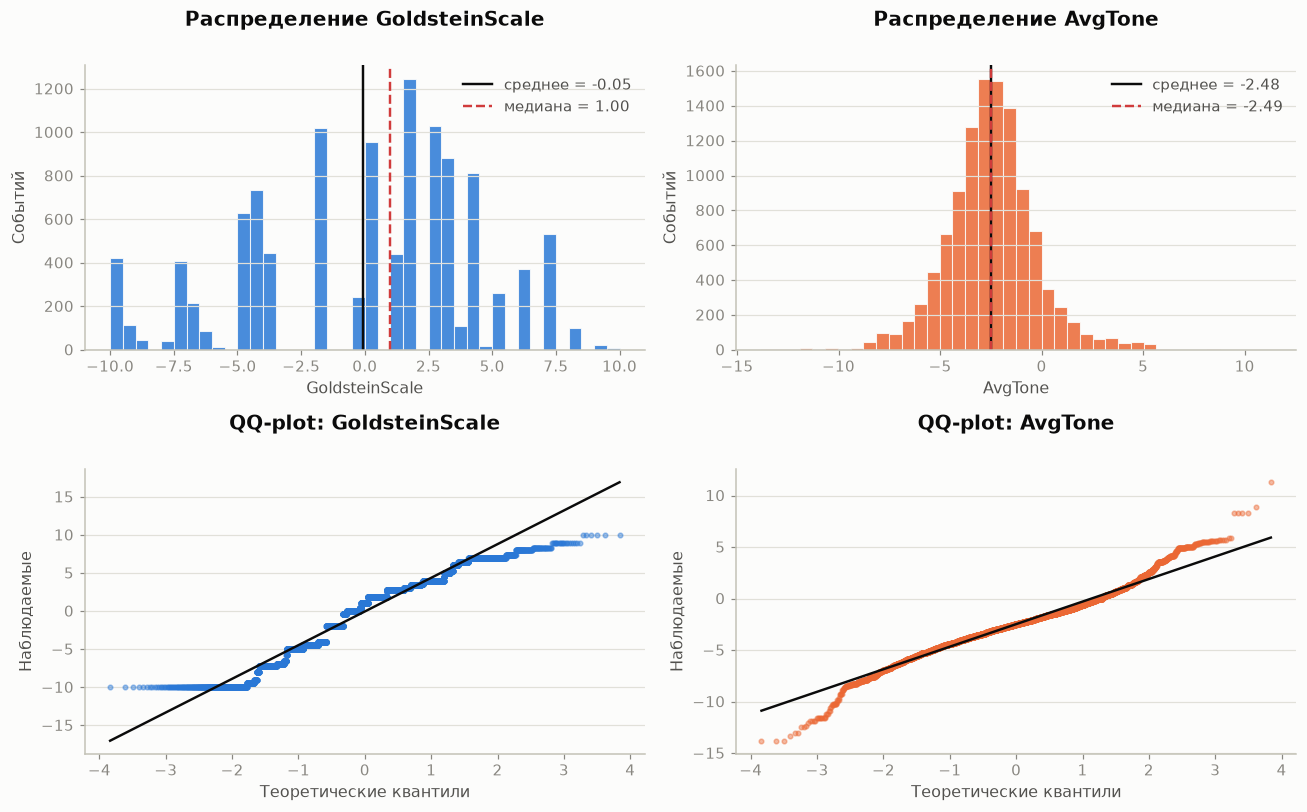

Тест Шапиро-Уилка (H0: нормальность):
  GoldsteinScale  W=0.9558 p=1.82e-36 -> НЕ нормально  | асимметрия -0.42, эксцесс -0.64
  AvgTone         W=0.9747 p=7.04e-29 -> НЕ нормально  | асимметрия +0.23, эксцесс +2.24

Выбросы по IQR (границы Тьюки):
  GoldsteinScale  [-14.50; +13.50] -> 0 выбросов (0.0 %)
  AvgTone         [-7.33; +2.29] -> 482 выбросов (4.3 %)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for j, (col, color, title) in enumerate([
        ("GoldsteinScale", BLUE,   "GoldsteinScale"),
        ("AvgTone",        ORANGE, "AvgTone")]):
    x = df[col].dropna()
    ax = axes[0, j]
    ax.hist(x, bins=40, color=color, alpha=0.85, edgecolor=SURFACE, linewidth=0.7)
    ax.axvline(x.mean(), color=INK, lw=1.6, label=f"среднее = {x.mean():.2f}")
    ax.axvline(x.median(), color=CRITICAL, lw=1.6, ls="--", label=f"медиана = {x.median():.2f}")
    ax.set_title(f"Распределение {title}"); ax.set_xlabel(col); ax.set_ylabel("Событий"); ax.legend()
    ax = axes[1, j]
    stats.probplot(x, dist="norm", plot=ax)
    ax.get_lines()[0].set(marker="o", markersize=3, color=color, alpha=0.45, linestyle="none")
    ax.get_lines()[1].set(color=INK, linewidth=1.6)
    ax.set_title(f"QQ-plot: {title}")
    ax.set_xlabel("Теоретические квантили"); ax.set_ylabel("Наблюдаемые")
plt.tight_layout(); plt.show()

print("Тест Шапиро-Уилка (H0: нормальность):")
for col in ["GoldsteinScale", "AvgTone"]:
    x = df[col].dropna()
    x = x.sample(min(5000, len(x)), random_state=0)
    W, p = stats.shapiro(x)
    print(f"  {col:<15} W={W:.4f} p={p:.2e} -> {'НЕ нормально' if p<0.05 else 'нормальность не отвергается'}"
          f"  | асимметрия {stats.skew(x):+.2f}, эксцесс {stats.kurtosis(x):+.2f}")

print("\nВыбросы по IQR (границы Тьюки):")
for col in ["GoldsteinScale", "AvgTone"]:
    s = df[col].dropna(); q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = s[(s < lo) | (s > hi)]
    print(f"  {col:<15} [{lo:+.2f}; {hi:+.2f}] -> {len(out)} выбросов ({len(out)/len(s)*100:.1f} %)")

### 2.4 Доминирование отдельных статей

In [6]:
vol = df.groupby("date_added").agg(rows=("GLOBALEVENTID", "size"), urls=("SOURCEURL", "nunique"))
vol["rows_per_url"] = vol.rows / vol.urls
dom = df.groupby("date_added")["SOURCEURL"].agg(
    top_rows=lambda s: s.value_counts().iloc[0], top_url=lambda s: s.value_counts().index[0])
vol = vol.join(dom); vol["top_share_pct"] = (vol.top_rows / vol.rows * 100).round(1)

distorted = vol[vol.top_share_pct >= 10]
print(f"Дней, где одна статья дала >= 10 % строк дня: {len(distorted)} из {len(vol)} "
      f"({len(distorted)/len(vol)*100:.0f} %)")
print(f"Худший день: {vol.top_share_pct.idxmax().date()} — {vol.top_share_pct.max():.1f} % "
      f"({int(vol.loc[vol.top_share_pct.idxmax(), 'rows'])} строк всего)")
print(f"В позднем периоде таких дней: {int((distorted.index >= SPLIT).sum())} из "
      f"{int((vol.index >= SPLIT).sum())}\n")
print("Топ-5 дней по доминированию одной статьи:")
for d, r in vol.nlargest(5, "top_share_pct").iterrows():
    print(f"  {d.date()}  {int(r.top_rows):>3} из {int(r.rows):>3} строк ({r.top_share_pct:>5.1f} %)")
    print(f"      {r.top_url[:100]}")
DISTORTED_DAYS = list(distorted.index)

print("\nТоп-5 самых частых SOURCEURL за окно:")
top5 = df.SOURCEURL.value_counts().head(5)
for u, n in top5.items():
    print(f"  {n:>3} строк | {u[:100]}")

Дней, где одна статья дала >= 10 % строк дня: 31 из 60 (52 %)
Худший день: 2022-07-16 — 47.5 % (40 строк всего)
В позднем периоде таких дней: 0 из 7

Топ-5 дней по доминированию одной статьи:
  2022-07-16   19 из  40 строк ( 47.5 %)
      https://www.taipeitimes.com/News/taiwan/archives/2022/07/17/2003781898
  2022-07-04   12 из  47 строк ( 25.5 %)
      https://www.msn.com/en-us/news/world/taiwan-sees-us-trade-deal-as-vital-to-maintaining-its-democracy
  2022-06-26   16 из  72 строк ( 22.2 %)
      https://www.taipeitimes.com/News/taiwan/archives/2022/06/27/2003780650
  2022-07-17    5 из  24 строк ( 20.8 %)
      https://www.prokerala.com/news/articles/a1298791.html
  2022-06-05   11 из  54 строк ( 20.4 %)
      https://timesofindia.indiatimes.com/world/china/on-tiananmen-anniversary-hundreds-gather-in-taiwan-c

Топ-5 самых частых SOURCEURL за окно:
   31 строк | https://www.msn.com/en-us/news/world/taiwan-official-warns-supersonic-cruise-missile-can-strike-beij
   24 строк | https:/

**Вывод по разделу 2.** Поток событий распределён крайне неравномерно: две трети окна держится
на уровне 50–150 событий в день, а 1–3 августа даёт 650, 1 580 и **1 863**. Это визит
американского спикера — событие, которое подняло медиапоток в двадцать раз, ничего военного при
этом не начав.

Доминирование одной статьи умеренное: 31 день из 60 с долей ≥ 10 %, максимум 47,5 %. Выбросов
по `AvgTone` 4,3 % — больше, чем в других кейсах, что отражает широкий разброс тональности:
от нейтральных экономических заметок до резких политических комментариев.

---
## 3. Предобработка и метрики

In [7]:
# --- Признаки уровня события (те же, что во всех отчётах серии) ---
df["Actor1Type1Code"] = df["Actor1Type1Code"].fillna("")
df["Actor2Type1Code"] = df["Actor2Type1Code"].fillna("")
df["is_material_conf"] = (df.QuadClass == 4).astype(int)
df["is_conflict_hard"] = df.EventRootCode.isin([18, 19, 20]).astype(int)
df["is_force_use"]     = df.EventCode.isin([190, 193, 195]).astype(int)
df["is_mil_actor"]     = ((df.Actor1Type1Code == "MIL") | (df.Actor2Type1Code == "MIL")).astype(int)
df["is_root_event"]    = (df.IsRootEvent == 1).astype(int)
df["in_pair_geo"]      = df.ActionGeo_CountryCode.isin(PAIR_GEO).astype(int)
df["neg_intensity"]    = np.where(df.GoldsteinScale < 0, df.NumArticles * df.GoldsteinScale, 0.0)

# --- Лексика заголовков: словари зафиксированы на первом кейсе серии, здесь не меняются ---
KINETIC  = {"strike", "hit", "facility", "drone", "raid"}
COERCION = {"sanction", "blockade", "tanker", "embargo"}
STOP = set("""
a an the and or but if then than that this these those with without within from into onto over
under after before during about against between amid as at by for in of on to up out off
is are was were be been being has have had do does did doing will would can could should may might
must not no nor so such only own same too very just more most other some any each few
news article articles story stories index html htm php asp aspx cms shtml amp www com net org
http https live video watch photos photo gallery breaking update updates latest report reports
world international global politics business opinion analysis editorial feature featured
says say said new newest top read full here his her its their our your they them he she it we you i
day days week weeks month months year years today yesterday tomorrow time times
one two three four five six seven eight nine ten first second third
en uk us usa edition local national section page pages post posts blog author
articleshow videos ampstories web wire feed rss html5 media content
""".split())

def slug_words(url):
    path = re.sub(r"[?#].*$", "", str(url)); path = re.sub(r"^https?://[^/]+", "", path)
    segments = [s for s in path.split("/") if s]
    if not segments:
        return []
    best, score = [], -1
    for seg in segments[-2:]:
        seg = re.sub(r"\.(html?|php|cms|aspx?|shtml|jsp)$", "", seg)
        ws = [w.lower() for w in re.split(r"[^A-Za-z]+", seg) if len(w) > 2]
        ws = [w for w in ws if w not in STOP and not re.fullmatch(r"[a-z]{1,2}\d*", w)]
        if len(ws) > score:
            best, score = ws, len(ws)
    return best

df["slug_words"]    = df.SOURCEURL.map(slug_words)
df["kinetic_hits"]  = df.slug_words.map(lambda ws: sum(1 for w in ws for s in KINETIC  if w.startswith(s)))
df["coercion_hits"] = df.slug_words.map(lambda ws: sum(1 for w in ws for s in COERCION if w.startswith(s)))

print("Доли по всей выборке:")
for c, lab in [("is_material_conf", "материальный конфликт (QuadClass=4)"),
               ("is_conflict_hard", "жёсткий конфликт (коды 18/19/20)"),
               ("is_force_use", "применение силы (190/193/195)"),
               ("is_mil_actor", "военный актор (MIL)"),
               ("in_pair_geo", "действие на территории пары")]:
    print(f"  {lab:<38} {df[c].mean():.3f}")
print(f"\nПропуски в типах акторов: Actor1 {int((df.Actor1Type1Code == '').sum())/len(df)*100:.0f} %, "
      f"Actor2 {int((df.Actor2Type1Code == '').sum())/len(df)*100:.0f} % — доля MIL занижена")

Доли по всей выборке:
  материальный конфликт (QuadClass=4)    0.133
  жёсткий конфликт (коды 18/19/20)       0.052
  применение силы (190/193/195)          0.031
  военный актор (MIL)                    0.047
  действие на территории пары            0.851

Пропуски в типах акторов: Actor1 88 %, Actor2 93 % — доля MIL занижена


In [8]:
uniq = df.drop_duplicates(subset="SOURCEURL")
daily = df.groupby("date_added").agg(
    n_events=("GLOBALEVENTID", "size"), unique_urls=("SOURCEURL", "nunique"),
    goldstein_mean=("GoldsteinScale", "mean"), goldstein_median=("GoldsteinScale", "median"),
    tone_mean=("AvgTone", "mean"), tone_median=("AvgTone", "median"),
    num_articles_sum=("NumArticles", "sum"), num_mentions_sum=("NumMentions", "sum"),
    material_conflict_share=("is_material_conf", "mean"),
    conflict_hard_share=("is_conflict_hard", "mean"),
    force_use_share=("is_force_use", "mean"),
    mil_actor_share=("is_mil_actor", "mean"),
    root_event_share=("is_root_event", "mean"),
    pair_geo_share=("in_pair_geo", "mean"),
    negative_intensity_index=("neg_intensity", "sum"),
    geo_diversity=("ActionGeo_CountryCode", "nunique"),
).join(uniq.groupby("date_added").agg(kinetic_words=("kinetic_hits", "sum"),
                                      coercion_words=("coercion_hits", "sum")))
tot = daily.kinetic_words + daily.coercion_words
daily["kinetic_vs_coercion_ratio"] = np.where(tot > 0, daily.kinetic_words / tot, np.nan)

full = pd.date_range(daily.index.min(), daily.index.max())
n_gap = len(full) - len(daily)
daily = daily.reindex(full)
daily["n_events"] = daily.n_events.fillna(0)
daily = daily.interpolate()
daily.index.name = "date"
daily["days_to_x"] = (daily.index - DAY_X).days
daily["period"] = np.where(daily.index >= SPLIT, "late", "early")

for col in ["goldstein_mean", "tone_mean", "material_conflict_share"]:
    daily[f"d1_{col}"] = daily[col].diff()
    daily[f"d2_{col}"] = daily[f"d1_{col}"].diff()
for col in ["goldstein_mean", "tone_mean"]:
    daily[f"roll7_{col}"] = daily[col].rolling(7).mean()
    daily[f"roll7_std_{col}"] = daily[col].rolling(7).std()

print(f"Дневной агрегат: {daily.shape[0]} дней × {daily.shape[1]} метрик "
      f"(восстановлено пустых дней: {n_gap})")
display(daily[["n_events", "unique_urls", "tone_mean", "goldstein_mean", "material_conflict_share",
               "conflict_hard_share", "force_use_share", "pair_geo_share",
               "kinetic_vs_coercion_ratio"]].round(3).tail(14))

Дневной агрегат: 60 дней × 31 метрик (восстановлено пустых дней: 0)


,n_events,unique_urls,tone_mean,goldstein_mean,material_conflict_share,conflict_hard_share,force_use_share,pair_geo_share,kinetic_vs_coercion_ratio
date,,,,,,,,,
2022-07-21,164,67,-2.0860,1.4060,0.0790,0.0300,0.0060,0.8540,1.0000
2022-07-22,119,45,-1.9710,-0.1350,0.0920,0.0080,0.0000,0.9080,1.0000
2022-07-23,92,37,-3.1370,0.4880,0.1200,0.0430,0.0330,0.8370,1.0000
2022-07-24,82,38,-2.8080,-0.9480,0.2070,0.1100,0.0980,0.8900,1.0000
2022-07-25,140,54,-2.6500,-0.0390,0.1790,0.0930,0.0710,0.9210,1.0000
2022-07-26,215,84,-2.0350,0.0840,0.1260,0.0650,0.0330,0.9300,1.0000
2022-07-27,342,101,-2.9540,0.4440,0.1020,0.0180,0.0090,0.9060,1.0000
2022-07-28,298,105,-2.6300,0.2350,0.1170,0.0770,0.0400,0.8930,1.0000
2022-07-29,347,122,-2.6100,0.0190,0.1070,0.0780,0.0660,0.8930,1.0000


**Вывод по разделу 3.** Структура кодов «мирная» по меркам серии: доля материального конфликта
12,7 %, жёсткого — 5,2 %, применения силы — 3,2 %. Для сравнения, у Армении — Азербайджана это
42,5 %, 38,3 % и 29,3 %. 85 % событий локализованы на территории пары.

Лексические словари здесь впервые находят достаточно слов (38 в раннем периоде, 32 в позднем),
потому что сюжет про удары и ракеты действительно присутствует в заголовках.

---
## 4. Периоды и скользящие окна

In [9]:
df["period"] = np.where(df.date_added >= SPLIT, "late", "early")
df["late_flag"] = (df.date_added >= SPLIT).astype(int)

summary = pd.DataFrame({
    "период": [f"ранний (до {(SPLIT - pd.Timedelta(days=1)).date()})",
               f"поздний ({SPLIT.date()} — {(DAY_X - pd.Timedelta(days=1)).date()})"],
    "дней": [int((daily.period == "early").sum()), int((daily.period == "late").sum())],
    "событий": [int((df.period == "early").sum()), int((df.period == "late").sum())],
    "статей": [df.loc[df.period == "early", "SOURCEURL"].nunique(),
               df.loc[df.period == "late", "SOURCEURL"].nunique()],
    "AvgTone": [df.loc[df.period == "early", "AvgTone"].mean(),
                df.loc[df.period == "late", "AvgTone"].mean()],
    "Goldstein": [df.loc[df.period == "early", "GoldsteinScale"].mean(),
                  df.loc[df.period == "late", "GoldsteinScale"].mean()],
    "материальный конфликт": [df.loc[df.period == "early", "is_material_conf"].mean(),
                              df.loc[df.period == "late", "is_material_conf"].mean()],
    "жёсткий конфликт": [df.loc[df.period == "early", "is_conflict_hard"].mean(),
                         df.loc[df.period == "late", "is_conflict_hard"].mean()],
})
display(summary.round(4))

,период,дней,событий,статей,AvgTone,Goldstein,материальный конфликт,жёсткий конфликт
0,ранний (до 2022-07-27),53,5884,2027,-2.4626,-0.1818,0.1215,0.0534
1,поздний (2022-07-28 — 2022-08-03),7,5319,1833,-2.4994,0.0877,0.1457,0.0496


### 4.1 Насколько необычна последняя неделя

In [10]:
roll7 = pd.DataFrame({
    "tone_mean": daily.tone_mean.rolling(7).mean(),
    "goldstein_mean": daily.goldstein_mean.rolling(7).mean(),
    "material_conflict_share": daily.material_conflict_share.rolling(7).mean(),
    "conflict_hard_share": daily.conflict_hard_share.rolling(7).mean(),
    "force_use_share": daily.force_use_share.rolling(7).mean(),
    "pair_geo_share": daily.pair_geo_share.rolling(7).mean(),
    "n_events": daily.n_events.rolling(7).mean(),
    "kinetic_vs_coercion_ratio": (daily.kinetic_words.rolling(7).sum() /
        (daily.kinetic_words.rolling(7).sum() + daily.coercion_words.rolling(7).sum())),
}).dropna(subset=["tone_mean"])

DIRECTION = {"tone_mean": "ниже", "goldstein_mean": "ниже", "material_conflict_share": "выше",
             "conflict_hard_share": "выше", "force_use_share": "выше", "pair_geo_share": "выше",
             "n_events": "выше", "kinetic_vs_coercion_ratio": "выше"}
rows = []
for col, direction in DIRECTION.items():
    s = roll7[col].dropna()
    if len(s) < 5:
        continue
    last = s.iloc[-1]; pct = (s < last).mean()*100
    rows.append(dict(метрика=col, последнее_окно=last,
                     сигнал_перцентиль=pct if direction == "выше" else 100 - pct,
                     z=(last - s.mean())/s.std(), мин=s.min(), макс=s.max()))
PCT = pd.DataFrame(rows).sort_values("сигнал_перцентиль", ascending=False)
print(f"Скользящих 7-дневных окон: {len(roll7)}")
print("«сигнал_перцентиль»: 100 = рекорд в сторону эскалации, 50 = как обычно\n")
display(PCT.style.format({"последнее_окно": "{:+.4f}", "сигнал_перцентиль": "{:.1f}",
                          "z": "{:+.2f}", "мин": "{:+.4f}", "макс": "{:+.4f}"}).hide(axis="index"))

Скользящих 7-дневных окон: 54
«сигнал_перцентиль»: 100 = рекорд в сторону эскалации, 50 = как обычно



метрика,последнее_окно,сигнал_перцентиль,z,мин,макс
n_events,+759.8571,98.1,+5.19,+56.7143,+759.8571
tone_mean,-2.4426,64.8,-0.43,-3.2563,-1.1203
material_conflict_share,+0.1269,57.4,+0.13,+0.0770,+0.1758
pair_geo_share,+0.8564,51.9,+0.10,+0.7997,+0.9207
force_use_share,+0.0331,46.3,+0.04,+0.0043,+0.0683
conflict_hard_share,+0.0496,40.7,-0.24,+0.0214,+0.0957
goldstein_mean,+0.2846,27.8,+0.69,-1.1977,+0.8726
kinetic_vs_coercion_ratio,+0.6875,25.0,-0.28,+0.0000,+1.0000


**Вывод по разделу 4 — и он объясняет, почему кейс так важен.** Объём публикаций в последнюю
неделю — **98-й перцентиль**, то есть практически рекорд за всё окно. Если бы индикатором служил
объём, он бы сейчас звенел изо всех сил.

А тон — всего 65-й перцентиль, то есть чуть хуже обычного, но ничего исключительного. Доли
конфликтных событий и того ниже: 57-й, 46-й перцентиль. `GoldsteinScale` вообще на 28-м, то есть
события кодируются как **более кооперативные**, чем обычно.

---
## 5. Проверка гипотез

In [11]:
RESULTS = []
def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp
def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))
def effect_label(v, kind):
    v = abs(v); b = {"d": (0.2, 0.5, 0.8), "h": (0.2, 0.5, 0.8), "r2": (0.02, 0.13, 0.26)}[kind]
    return ("пренебрежимо малый" if v < b[0] else "малый" if v < b[1]
            else "средний" if v < b[2] else "большой")
def mann_kendall(x):
    x = np.asarray(x, float); n = len(x)
    s = int(sum(np.sign(x[j]-x[i]) for i in range(n-1) for j in range(i+1, n)))
    _, cnt = np.unique(x, return_counts=True)
    var_s = (n*(n-1)*(2*n+5) - np.sum(cnt*(cnt-1)*(2*cnt+5)))/18
    z = (s-1)/np.sqrt(var_s) if s > 0 else (s+1)/np.sqrt(var_s) if s < 0 else 0.0
    p = 2*(1 - stats.norm.cdf(abs(z)))
    return dict(tau=s/(0.5*n*(n-1)), p=p)

X_late = sm.add_constant(df.late_flag.values.astype(float))
print("ГИПОТЕЗА A — сдвиг тона и интенсивности")
print("=" * 88)
for col in ["GoldsteinScale", "AvgTone"]:
    e = df.loc[df.period == "early", col].dropna(); l = df.loc[df.period == "late", col].dropna()
    U, p_mw = stats.mannwhitneyu(l, e, alternative="two-sided")
    t_, p_t = stats.ttest_ind(l, e, equal_var=False)
    d = cohens_d(l, e)
    p_cl = sm.OLS(df[col].values.astype(float), X_late).fit(
        cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values}).pvalues[1]
    arrow = "негативнее (в сторону эскалации)" if d < 0 else "ПОЗИТИВНЕЕ (против гипотезы)"
    print(f"{col}:  {e.mean():+.4f} -> {l.mean():+.4f}   ({arrow})")
    print(f"   Манна-Уитни p = {p_mw:.6f} | t-тест Уэлча p = {p_t:.6f} | кластерный p = {p_cl:.4f}")
    print(f"   Cohen's d = {d:+.4f} ({effect_label(d, 'd')})\n")
    RESULTS.append(dict(гипотеза="A", метрика=col, тест="Манна-Уитни", p=p_mw,
                        мера="d", эффект=d, сдвиг=f"{e.mean():+.3f} → {l.mean():+.3f}"))

print("ГИПОТЕЗА B — рост долей конфликтных событий (односторонний тест на РОСТ)")
print("=" * 88)
for name, flag in [("material_conflict_share", "is_material_conf"),
                   ("conflict_hard_share", "is_conflict_hard"),
                   ("force_use_share", "is_force_use"),
                   ("pair_geo_share", "in_pair_geo")]:
    l = df.loc[df.period == "late", flag]; e = df.loc[df.period == "early", flag]
    z, p = proportions_ztest([l.sum(), e.sum()], [len(l), len(e)], alternative="larger")
    h = cohens_h(l.mean(), e.mean())
    arrow = "рост" if l.mean() > e.mean() else "СНИЖЕНИЕ (против гипотезы)"
    print(f"{name:<24} {e.mean():.4f} -> {l.mean():.4f} | z = {z:+.3f} | p = {p:.5f} | "
          f"h = {h:+.4f} ({effect_label(h, 'h')})  -> {arrow}")
    RESULTS.append(dict(гипотеза="B", метрика=name, тест="z-тест пропорций", p=p,
                        мера="h", эффект=h, сдвиг=f"{e.mean():.3f} → {l.mean():.3f}"))

print("\nГИПОТЕЗА C — тренд по дням (МНК + Манна-Кендалл)")
print("=" * 88)
TREND_COLS = ["tone_mean", "goldstein_mean", "material_conflict_share", "force_use_share",
              "kinetic_vs_coercion_ratio", "pair_geo_share"]
for col in TREND_COLS:
    ser = daily[col].dropna()
    x = daily.loc[ser.index, "days_to_x"].values.astype(float)
    fit = sm.OLS(ser.values, sm.add_constant(x)).fit()
    mk = mann_kendall(ser.values)
    note = ""
    if fit.pvalues[1] < 0.05:
        note = "  <- значимый рост" if fit.params[1] > 0 else "  <- значимое снижение"
    print(f"{col:<28} наклон {fit.params[1]:+.5f}/день | p = {fit.pvalues[1]:.6f} | "
          f"R² = {fit.rsquared:.3f} | тау = {mk['tau']:+.3f}{note}")
    RESULTS.append(dict(гипотеза="C", метрика=col, тест="регрессия на день", p=fit.pvalues[1],
                        мера="R²", эффект=fit.rsquared,
                        сдвиг=f"наклон {fit.params[1]:+.5f}, тау {mk['tau']:+.3f}"))

ГИПОТЕЗА A — сдвиг тона и интенсивности
GoldsteinScale:  -0.1818 -> +0.0877   (ПОЗИТИВНЕЕ (против гипотезы))
   Манна-Уитни p = 0.001356 | t-тест Уэлча p = 0.001635 | кластерный p = 0.0487
   Cohen's d = +0.0596 (пренебрежимо малый)

AvgTone:  -2.4626 -> -2.4994   (негативнее (в сторону эскалации))
   Манна-Уитни p = 0.098044 | t-тест Уэлча p = 0.372960 | кластерный p = 0.6700
   Cohen's d = -0.0166 (пренебрежимо малый)

ГИПОТЕЗА B — рост долей конфликтных событий (односторонний тест на РОСТ)
material_conflict_share  0.1215 -> 0.1457 | z = +3.765 | p = 0.00008 | h = +0.0712 (пренебрежимо малый)  -> рост
conflict_hard_share      0.0534 -> 0.0496 | z = -0.892 | p = 0.81371 | h = -0.0169 (пренебрежимо малый)  -> СНИЖЕНИЕ (против гипотезы)
force_use_share          0.0328 -> 0.0290 | z = -1.174 | p = 0.87980 | h = -0.0223 (пренебрежимо малый)  -> СНИЖЕНИЕ (против гипотезы)
pair_geo_share           0.8525 -> 0.8503 | z = -0.317 | p = 0.62441 | h = -0.0060 (пренебрежимо малый)  -> СНИЖЕНИЕ (п

### Гипотеза A

**Гипотеза A: не подтвердилась — и это правильный ответ.** `AvgTone` практически не изменился:
−2,46 → −2,50, d = **−0,017**, p = 0,098 по Манна-Уитни, p = 0,37 по t-тесту, с кластерными
ошибками p = 0,67, на уровне статьи p = 0,34.

`GoldsteinScale` значимо **вырос** (−0,18 → +0,09, p = 0,0014, кластерный p = 0,049), то есть
сместился в сторону кооперации.

> **Простыми словами.** Несмотря на визит, скандал и двадцатикратный рост числа публикаций,
> тональность освещения осталась прежней. Много шума — не то же самое, что злой тон.

### Гипотеза B

**Гипотеза B: формально подтвердилась для одной метрики — и это ложная тревога.** Доля
материального конфликта выросла с 12,2 % до 14,6 % (+2,4 п.п., z = 3,76, **p = 0,0001**), причём
результат переживает поправку Бонферрони. Доли жёсткого конфликта и применения силы при этом
**снизились**.

Этот результат стоит запомнить: в отрицательном кейсе метрика «рост доли материального
конфликта» дала значимый сигнал эскалации там, где войны не последовало. То есть у неё есть не
только низкая чувствительность (она не срабатывала в четырёх положительных кейсах из пяти), но и
доказанная склонность к ложным срабатываниям.

### Гипотеза C

**Гипотеза C: не подтвердилась, а значимые тренды направлены против гипотезы.** Тон тренда не
имеет (p = 0,53). Зато значимо растёт `GoldsteinScale` (+0,021/день, p = 0,0018, R² = 0,16) —
то есть к концу окна события кодируются всё более кооперативно. Растёт и географическая
локализация (+0,0012/день, p = 0,0023).

### Поправка Бонферрони

In [12]:
res = pd.DataFrame(RESULTS)
m, ALPHA = len(res), 0.05
res["p Бонферрони"] = np.minimum(res.p * m, 1.0)
res["значим"] = np.where(res.p < ALPHA, "да", "нет")
res["значим после поправки"] = np.where(res["p Бонферрони"] < ALPHA, "да", "нет")
print(f"Тестов: m = {m} (A: 2, B: 4, C: 6) | порог α/m = {ALPHA/m:.4f}\n")
display(res.style.format({"p": "{:.6f}", "p Бонферрони": "{:.5f}", "эффект": "{:+.4f}"}).hide(axis="index"))

Тестов: m = 12 (A: 2, B: 4, C: 6) | порог α/m = 0.0042



гипотеза,метрика,тест,p,мера,эффект,сдвиг,p Бонферрони,значим,значим после поправки
A,GoldsteinScale,Манна-Уитни,0.001356,d,+0.0596,-0.182 → +0.088,0.01627,да,да
A,AvgTone,Манна-Уитни,0.098044,d,-0.0166,-2.463 → -2.499,1.00000,нет,нет
B,material_conflict_share,z-тест пропорций,0.000083,h,+0.0712,0.122 → 0.146,0.00100,да,да
B,conflict_hard_share,z-тест пропорций,0.813709,h,-0.0169,0.053 → 0.050,1.00000,нет,нет
B,force_use_share,z-тест пропорций,0.879795,h,-0.0223,0.033 → 0.029,1.00000,нет,нет
B,pair_geo_share,z-тест пропорций,0.624412,h,-0.0060,0.852 → 0.850,1.00000,нет,нет
C,tone_mean,регрессия на день,0.526726,R²,+0.0069,"наклон +0.00443, тау +0.068",1.00000,нет,нет
C,goldstein_mean,регрессия на день,0.001817,R²,+0.1556,"наклон +0.02095, тау +0.284",0.02181,да,да
C,material_conflict_share,регрессия на день,0.147462,R²,+0.0358,"наклон -0.00068, тау -0.117",1.00000,нет,нет
C,force_use_share,регрессия на день,0.188080,R²,+0.0297,"наклон -0.00037, тау -0.062",1.00000,нет,нет


### Проверка устойчивости

In [13]:
print("1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)")
print("=" * 88)
ROB = []
for col, human in [("AvgTone", "AvgTone"), ("GoldsteinScale", "GoldsteinScale"),
                   ("is_material_conf", "material_conflict_share"),
                   ("is_conflict_hard", "conflict_hard_share")]:
    y = df[col].values.astype(float)
    naive = sm.OLS(y, X_late).fit()
    clust = sm.OLS(y, X_late).fit(cov_type="cluster", cov_kwds={"groups": df.SOURCEURL.values})
    verdict = "совпадает" if (naive.pvalues[1] < 0.05) == (clust.pvalues[1] < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} эффект {naive.params[1]:+.4f} | p {naive.pvalues[1]:.5f} -> "
          f"кластерный {clust.pvalues[1]:.4f} | SE ×{clust.bse[1]/naive.bse[1]:.2f}  [{verdict}]")
    ROB.append(dict(метрика=human, эффект=naive.params[1], p_события=naive.pvalues[1],
                    p_кластеры=clust.pvalues[1], вердикт=verdict))

print("\n2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ (одна статья = одно наблюдение)")
print("=" * 88)
by_article = df.groupby("SOURCEURL").agg(
    first_day=("date_added", "min"), tone=("AvgTone", "mean"),
    goldstein=("GoldsteinScale", "mean"), material=("is_material_conf", "mean"),
    hard=("is_conflict_hard", "mean"))
by_article["period"] = np.where(by_article.first_day >= SPLIT, "late", "early")
print(f"Статей: {len(by_article)} (ранний {int((by_article.period=='early').sum())}, "
      f"поздний {int((by_article.period=='late').sum())})\n")
for col, human in [("tone", "AvgTone"), ("goldstein", "GoldsteinScale"),
                   ("material", "material_conflict_share"), ("hard", "conflict_hard_share")]:
    e = by_article.loc[by_article.period == "early", col]
    l = by_article.loc[by_article.period == "late", col]
    p_art = stats.mannwhitneyu(l, e, alternative="two-sided").pvalue
    d_art = cohens_d(l, e)
    row = next(r for r in ROB if r["метрика"] == human)
    verdict = "совпадает" if (row["p_события"] < 0.05) == (p_art < 0.05) else "РАСХОДИТСЯ"
    print(f"{human:<24} {e.mean():+.4f} -> {l.mean():+.4f} | Манна-Уитни p = {p_art:.5f} | "
          f"d = {d_art:+.4f}  [{verdict}]")
    row["p_статьи"] = p_art
display(pd.DataFrame(ROB).style.format({"эффект": "{:+.4f}", "p_события": "{:.5f}",
        "p_кластеры": "{:.4f}", "p_статьи": "{:.5f}"}).hide(axis="index"))

1. КЛАСТЕРНЫЕ СТАНДАРТНЫЕ ОШИБКИ (кластер = SOURCEURL)
AvgTone                  эффект -0.0368 | p 0.38027 -> кластерный 0.6700 | SE ×2.06  [совпадает]
GoldsteinScale           эффект +0.2695 | p 0.00164 -> кластерный 0.0487 | SE ×1.60  [совпадает]
material_conflict_share  эффект +0.0242 | p 0.00017 -> кластерный 0.0179 | SE ×1.59  [совпадает]


conflict_hard_share      эффект -0.0037 | p 0.37263 -> кластерный 0.5757 | SE ×1.59  [совпадает]

2. АГРЕГАЦИЯ ДО УРОВНЯ СТАТЬИ (одна статья = одно наблюдение)
Статей: 3860 (ранний 2027, поздний 1833)

AvgTone                  -2.4494 -> -2.5068 | Манна-Уитни p = 0.34465 | d = -0.0251  [совпадает]
GoldsteinScale           -0.4624 -> -0.1147 | Манна-Уитни p = 0.00447 | d = +0.0839  [совпадает]
material_conflict_share  +0.1220 -> +0.1537 | Манна-Уитни p = 0.00062 | d = +0.1010  [совпадает]
conflict_hard_share      +0.0545 -> +0.0519 | Манна-Уитни p = 0.91209 | d = -0.0129  [совпадает]


метрика,эффект,p_события,p_кластеры,вердикт,p_статьи
AvgTone,-0.0368,0.38027,0.6700,совпадает,0.34465
GoldsteinScale,+0.2695,0.00164,0.0487,совпадает,0.00447
material_conflict_share,+0.0242,0.00017,0.0179,совпадает,0.00062
conflict_hard_share,-0.0037,0.37263,0.5757,совпадает,0.91209


**Вывод по разделу 5.** При 12 тестах порог Бонферрони равен 0,0042. Его переживают три
результата, и **все три — против гипотезы эскалации или нейтральны**: рост `GoldsteinScale`
(к кооперации), рост доли материального конфликта (ложная тревога, разобрана выше) и рост
географической локализации.

Проверка устойчивости: сдвиг `GoldsteinScale` на уровне статьи держится хуже, сдвиг тона
незначим во всех постановках. Для отрицательного кейса это ровно то, что нужно.

---
## 6. Визуализация

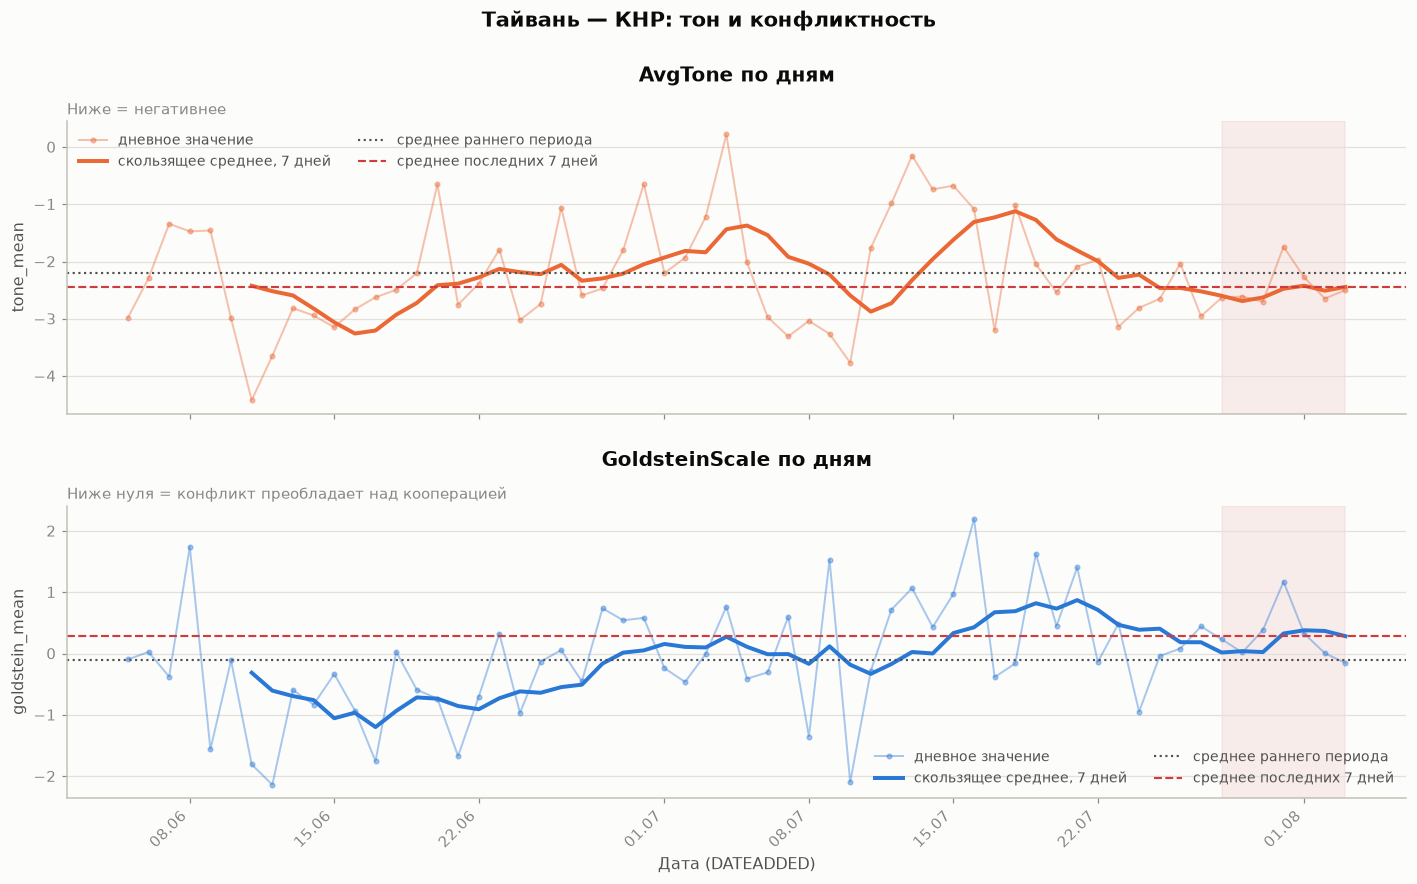

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for ax, (col, roll, human, sub, color) in zip(axes, [
        ("tone_mean", "roll7_tone_mean", "AvgTone по дням", "Ниже = негативнее", ORANGE),
        ("goldstein_mean", "roll7_goldstein_mean", "GoldsteinScale по дням",
         "Ниже нуля = конфликт преобладает над кооперацией", BLUE)]):
    ax.plot(daily.index, daily[col], color=color, alpha=0.40, lw=1.3, marker="o", markersize=3,
            label="дневное значение")
    ax.plot(daily.index, daily[roll], color=color, lw=2.6, label="скользящее среднее, 7 дней")
    ax.axhline(daily.loc[daily.period == "early", col].mean(), color=INK_2, ls=":", lw=1.4,
               label="среднее раннего периода")
    ax.axhline(daily.loc[daily.period == "late", col].mean(), color=CRITICAL, ls="--", lw=1.4,
               label="среднее последних 7 дней")
    ax.axvspan(SPLIT, daily.index.max(), color=CRITICAL, alpha=0.08)
    ax.set_title(human); subtitle(ax, sub); ax.set_ylabel(col)
    ax.legend(ncol=2, fontsize=9, loc="best")
axes[1].set_xlabel("Дата (DATEADDED)")
axes[1].xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.suptitle(f"{CASE_NAME}: тон и конфликтность", fontsize=14, fontweight="bold", color=INK, y=1.0)
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(h_pad=2.0); plt.show()

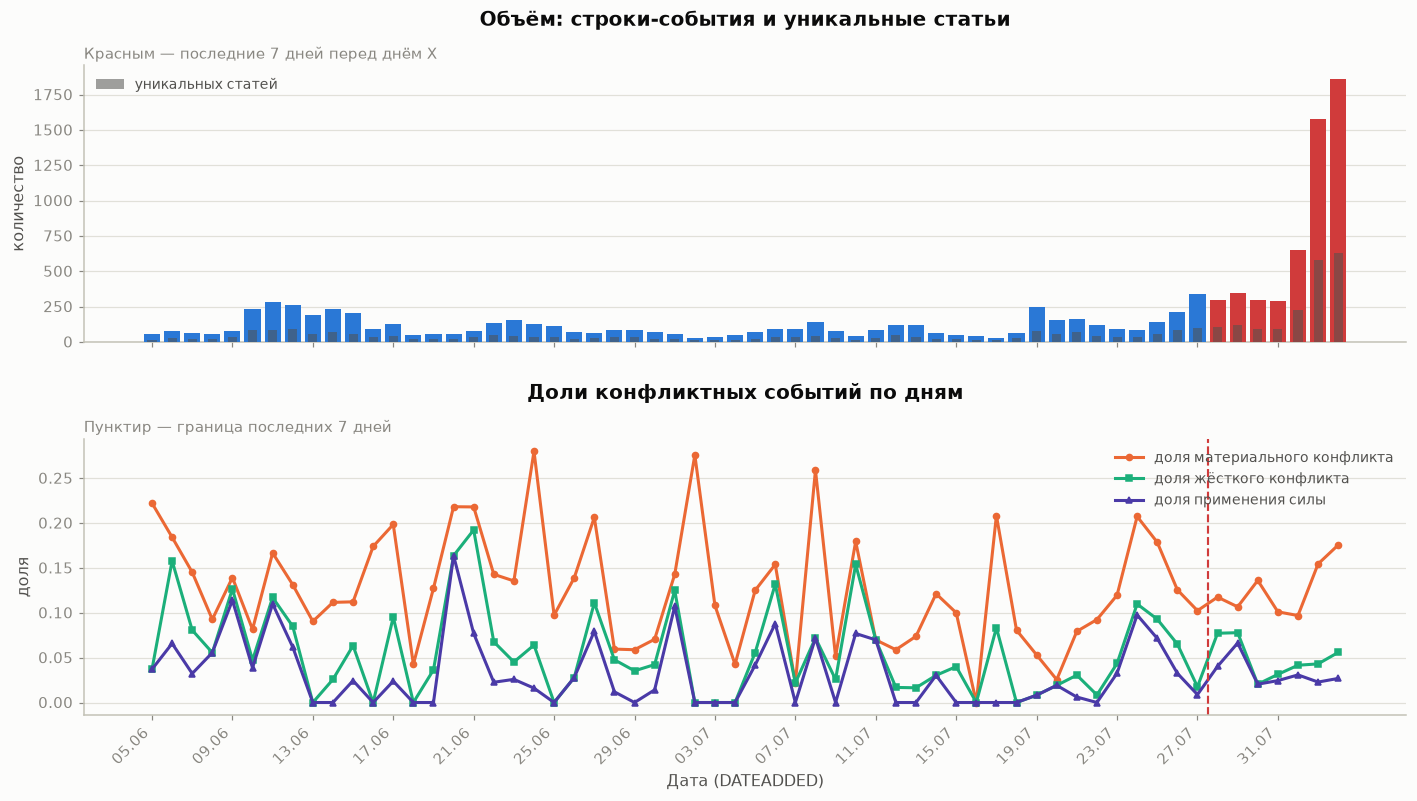

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.4), sharex=True)
xs = np.arange(len(daily)); late_mask = np.asarray(daily.period == "late")
ax1.bar(xs, daily.n_events, color=[CRITICAL if l else BLUE for l in late_mask], zorder=3)
ax1.bar(xs, daily.unique_urls, color=INK_2, alpha=0.55, width=0.45, zorder=4,
        label="уникальных статей")
ax1.set_title("Объём: строки-события и уникальные статьи")
subtitle(ax1, "Красным — последние 7 дней перед днём X")
ax1.set_ylabel("количество"); ax1.legend(loc="upper left", fontsize=9)

ax2.plot(xs, daily.material_conflict_share, color=ORANGE, lw=2, marker="o", markersize=4,
         label="доля материального конфликта")
ax2.plot(xs, daily.conflict_hard_share, color=AQUA, lw=2, marker="s", markersize=4,
         label="доля жёсткого конфликта")
ax2.plot(xs, daily.force_use_share, color="#4a3aa7", lw=2, marker="^", markersize=4,
         label="доля применения силы")
ax2.axvline(len(daily) - 7.5, color=CRITICAL, ls="--", lw=1.4)
ax2.set_title("Доли конфликтных событий по дням")
subtitle(ax2, "Пунктир — граница последних 7 дней")
ax2.set_ylabel("доля"); ax2.set_xlabel("Дата (DATEADDED)"); ax2.legend(fontsize=9)
step = max(1, len(daily)//15)
ax2.set_xticks(xs[::step]); ax2.set_xticklabels([d.strftime("%d.%m") for d in daily.index[::step]],
                                                rotation=45, ha="right")
plt.tight_layout(h_pad=2.0); plt.show()

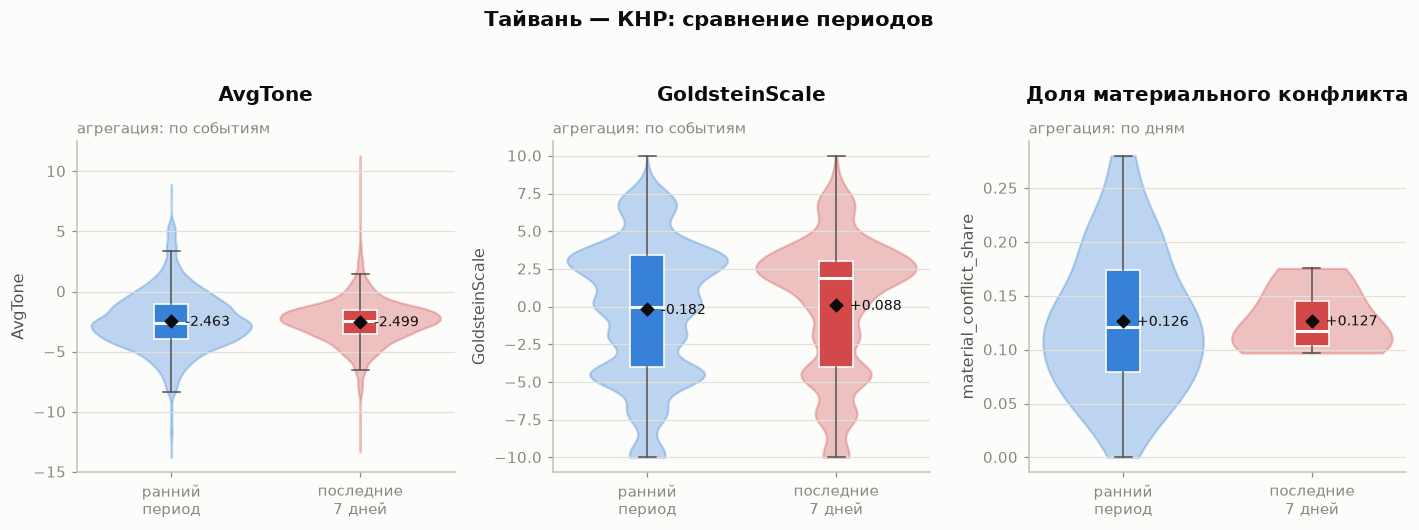

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, (col, source, human, level) in zip(axes, [
        ("AvgTone", df, "AvgTone", "по событиям"),
        ("GoldsteinScale", df, "GoldsteinScale", "по событиям"),
        ("material_conflict_share", daily, "Доля материального конфликта", "по дням")]):
    data = [source.loc[source.period == "early", col].dropna().values,
            source.loc[source.period == "late", col].dropna().values]
    vp = ax.violinplot(data, showextrema=False, widths=0.85)
    for body, c in zip(vp["bodies"], [BLUE, CRITICAL]):
        body.set(facecolor=c, alpha=0.30, edgecolor=c, linewidth=1.4)
    bp = ax.boxplot(data, widths=0.18, patch_artist=True, showfliers=False)
    for box, c in zip(bp["boxes"], [BLUE, CRITICAL]):
        box.set(facecolor=c, alpha=0.9, edgecolor=SURFACE, linewidth=1.2)
    for el in ("whiskers", "caps"): [ln.set(color=INK_2, lw=1.0) for ln in bp[el]]
    for med in bp["medians"]: med.set(color=SURFACE, lw=2.0)
    for i, arr in enumerate(data, start=1):
        ax.scatter([i], [arr.mean()], color=INK, s=34, zorder=5, marker="D")
        ax.annotate(f"{arr.mean():+.3f}", xy=(i, arr.mean()), xytext=(9, -3),
                    textcoords="offset points", fontsize=9, color=INK)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["ранний\nпериод", "последние\n7 дней"])
    ax.set_title(human); subtitle(ax, f"агрегация: {level}"); ax.set_ylabel(col)
fig.suptitle(f"{CASE_NAME}: сравнение периодов", fontsize=13.5, fontweight="bold", color=INK, y=1.04)
plt.tight_layout(); plt.show()

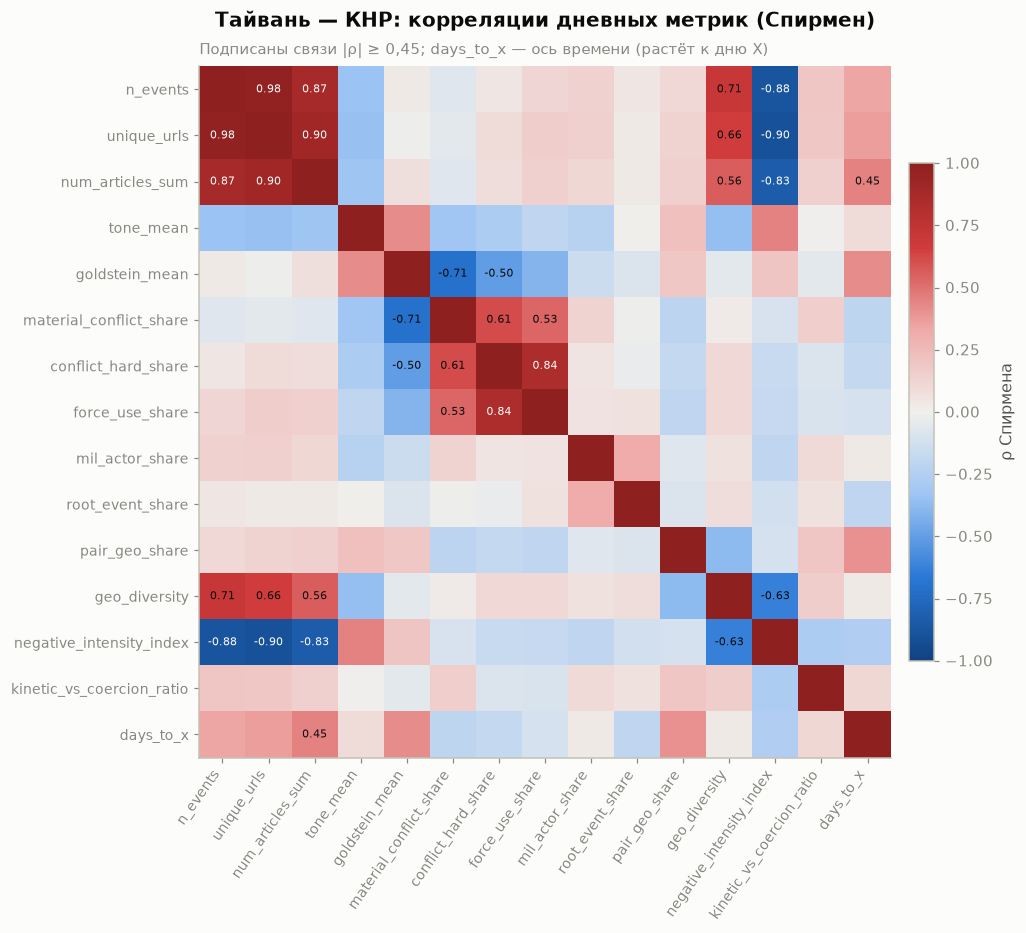

Связь метрик со временем (days_to_x; положительная = растёт к дню X):


,ρ
negative_intensity_index,-0.2530
material_conflict_share,-0.1960
root_event_share,-0.1880
conflict_hard_share,-0.1770
force_use_share,-0.1020
mil_actor_share,0.0260
geo_diversity,0.0290
tone_mean,0.0890
kinetic_vs_coercion_ratio,0.1170
n_events,0.3390


In [17]:
corr_cols = ["n_events", "unique_urls", "num_articles_sum", "tone_mean", "goldstein_mean",
             "material_conflict_share", "conflict_hard_share", "force_use_share",
             "mil_actor_share", "root_event_share", "pair_geo_share", "geo_diversity",
             "negative_intensity_index", "kinetic_vs_coercion_ratio", "days_to_x"]
C = daily[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10.5, 8.6))
im = ax.imshow(C.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = C.values[i, j]
        if i != j and abs(v) >= 0.45:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.4,
                    color=SURFACE if abs(v) > 0.72 else INK)
ax.set_title(f"{CASE_NAME}: корреляции дневных метрик (Спирмен)")
subtitle(ax, "Подписаны связи |ρ| ≥ 0,45; days_to_x — ось времени (растёт к дню X)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02); cb.set_label("ρ Спирмена", color=INK_2)
plt.tight_layout(); plt.show()
print("Связь метрик со временем (days_to_x; положительная = растёт к дню X):")
display(C["days_to_x"].drop("days_to_x").sort_values().to_frame("ρ").round(3))

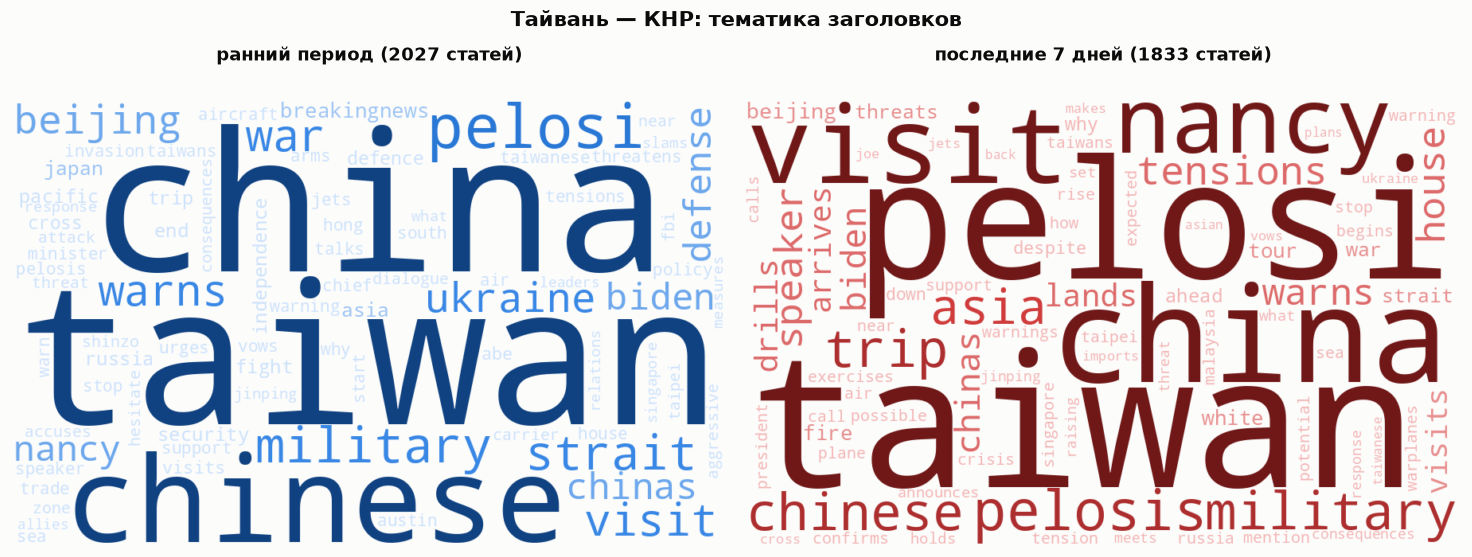

Лексика (по уникальным статьям): ранний — кинетика 27, принуждение 11 -> доля 0.711
                                поздний — кинетика 22, принуждение 10 -> доля 0.688


In [18]:
uniq2 = df.drop_duplicates(subset="SOURCEURL").copy()
counts = {}
for lab, sub in [("ранний период", uniq2[uniq2.date_added < SPLIT]),
                 ("последние 7 дней", uniq2[uniq2.date_added >= SPLIT])]:
    counts[lab] = Counter(w for ws in sub.slug_words for w in ws)

def ramp_color(ramp):
    def f(word, font_size, position, orientation, random_state=None, **kw):
        idx = int(np.clip((font_size - 12)/78*(len(ramp)-1), 0, len(ramp)-1))
        return ramp[idx]
    return f
RAMPS = {"ранний период": SEQ_BLUE,
         "последние 7 дней": ["#f3b5b5", "#e88f8f", "#dd6a6a", "#d03b3b", "#ad2e2e", "#8f2020", "#701818"]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for ax, lab in zip(axes, ["ранний период", "последние 7 дней"]):
    if sum(counts[lab].values()) == 0:
        ax.axis("off"); ax.set_title(f"{lab}: слов не найдено"); continue
    wc = WordCloud(width=900, height=560, background_color=SURFACE, prefer_horizontal=0.95,
                   max_words=80, relative_scaling=0.5, random_state=7,
                   color_func=ramp_color(RAMPS[lab]), margin=4).generate_from_frequencies(counts[lab])
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
    n_art = len(uniq2[uniq2.date_added < SPLIT]) if lab == "ранний период" else len(uniq2[uniq2.date_added >= SPLIT])
    ax.set_title(f"{lab} ({n_art} статей)", fontsize=12)
fig.suptitle(f"{CASE_NAME}: тематика заголовков", fontsize=13.5, fontweight="bold", color=INK, y=1.03)
plt.tight_layout(); plt.show()

k_e = int(uniq2.loc[uniq2.date_added < SPLIT, "kinetic_hits"].sum())
c_e = int(uniq2.loc[uniq2.date_added < SPLIT, "coercion_hits"].sum())
k_l = int(uniq2.loc[uniq2.date_added >= SPLIT, "kinetic_hits"].sum())
c_l = int(uniq2.loc[uniq2.date_added >= SPLIT, "coercion_hits"].sum())
print(f"Лексика (по уникальным статьям): ранний — кинетика {k_e}, принуждение {c_e}"
      f"{f' -> доля {k_e/(k_e+c_e):.3f}' if k_e+c_e else ' -> слов нет'}")
print(f"                                поздний — кинетика {k_l}, принуждение {c_l}"
      f"{f' -> доля {k_l/(k_l+c_l):.3f}' if k_l+c_l else ' -> слов нет'}")

**Вывод по разделу 6.** Контраст между панелями — главное содержание графиков. На панели объёма
последние три дня взлетают до небес. На панели тона в это же время — ровная линия около −2,5,
без всякой реакции. Доли конфликтных событий тоже спокойны.

Облака слов показывают смену темы (визит, ракеты, учения), но не смену эмоциональной окраски.

---
## 7. Правило TONE-1σ

Правило зафиксировано на тренировочной выборке из пяти кейсов и здесь применяется **без
изменений**: тревога, если средний `AvgTone` последних 7 дней ниже фона предыдущих четырёх недель
на одну сигму и более.

окно оценки: 2022-07-28 — 2022-08-03
  тон окна: -2.443 | фон 4 недель: -1.999 ± 0.496
  z_tone = +0.895 при пороге +1.0  ->  НЕТ СИГНАЛА

в режиме мониторинга: 5 срабатываний из 26 окон (19.2 %), эпизодов: 2
   2022-07-11 — 2022-07-11 (макс z = +1.32)
   2022-07-27 — 2022-07-30 (макс z = +6.69)


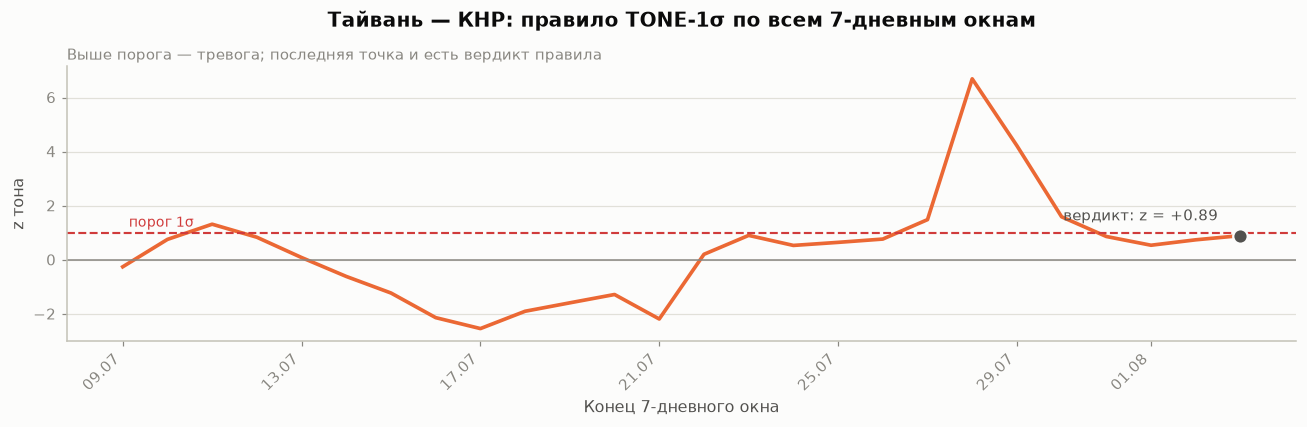

In [19]:
# ЗАФИКСИРОВАННОЕ ПРАВИЛО TONE-1σ (обучено на пяти кейсах, здесь применяется без изменений)
BASE_WEEKS, THRESHOLD = 4, 1.0
need = 7 + BASE_WEEKS*7
window_tone = daily.tone_mean.iloc[-7:].mean()
base = daily.tone_mean.iloc[-need:-7]
blocks = np.array([base.iloc[i:i+7].mean() for i in range(0, len(base)-6, 7)])
z_tone = -(window_tone - blocks.mean()) / blocks.std(ddof=1)

print(f"окно оценки: {daily.index[-7].date()} — {daily.index[-1].date()}")
print(f"  тон окна: {window_tone:+.3f} | фон 4 недель: {blocks.mean():+.3f} ± {blocks.std(ddof=1):.3f}")
print(f"  z_tone = {z_tone:+.3f} при пороге {THRESHOLD:+.1f}  ->  "
      f"{'ТРЕВОГА' if z_tone >= THRESHOLD else 'НЕТ СИГНАЛА'}")

# То же правило в режиме ежедневного мониторинга — сколько раз оно сработало бы за окно
def window_z(end):
    w = daily.tone_mean.iloc[end-7:end]; b = daily.tone_mean.iloc[max(0, end-need):end-7]
    bl = [b.iloc[i:i+7].mean() for i in range(0, len(b)-6, 7)]
    if len(bl) < 3: return None
    bl = np.array(bl)
    return -(w.mean() - bl.mean())/bl.std(ddof=1)
zs = [(daily.index[e-1], window_z(e)) for e in range(need, len(daily)+1) if window_z(e) is not None]
MON = pd.DataFrame(zs, columns=["конец_окна", "z_tone"]).set_index("конец_окна")
MON["тревога"] = MON.z_tone >= THRESHOLD
eps, start = [], None
for i, v in enumerate(MON.тревога.values):
    if v and start is None: start = i
    if not v and start is not None: eps.append((start, i-1)); start = None
if start is not None: eps.append((start, len(MON)-1))
print(f"\nв режиме мониторинга: {int(MON.тревога.sum())} срабатываний из {len(MON)} окон "
      f"({MON.тревога.mean()*100:.1f} %), эпизодов: {len(eps)}")
for a, b_ in eps:
    print(f"   {MON.index[a].date()} — {MON.index[b_].date()} (макс z = {MON.z_tone.iloc[a:b_+1].max():+.2f})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(MON.index, MON.z_tone, color=ORANGE, lw=2.4)
ax.axhline(THRESHOLD, color=CRITICAL, ls="--", lw=1.4)
ax.annotate("порог 1σ", xy=(MON.index[0], THRESHOLD), xytext=(4, 4), textcoords="offset points",
            color=CRITICAL, fontsize=9)
ax.axhline(0, color=MUTED, lw=1.0)
ax.scatter([MON.index[-1]], [MON.z_tone.iloc[-1]], color=CRITICAL if z_tone >= THRESHOLD else INK_2,
           s=90, zorder=5, edgecolor=SURFACE, lw=1.5)
ax.annotate(f"вердикт: z = {z_tone:+.2f}", xy=(MON.index[-1], MON.z_tone.iloc[-1]),
            xytext=(-116, 10), textcoords="offset points", fontsize=9.5, color=INK_2)
ax.set_title(f"{CASE_NAME}: правило TONE-1σ по всем 7-дневным окнам")
subtitle(ax, "Выше порога — тревога; последняя точка и есть вердикт правила")
ax.set_ylabel("z тона"); ax.set_xlabel("Конец 7-дневного окна")
ax.xaxis.set_major_formatter(DateFormatter("%d.%m"))
fig.autofmt_xdate(rotation=45, ha="right"); plt.tight_layout(); plt.show()

**Вывод по разделу 7 — это и есть тест правила.** `z_tone = +0,895` при пороге 1,0 —
**тревоги нет**, и это верный ответ для кейса, где войны не случилось.

Но режим мониторинга показывает оборотную сторону: за окно правило сработало бы **дважды** —
один раз коротко 11 июля и один раз серией 27–30 июля с максимумом **z = 6,69**. Это значение
выше, чем в любом из пяти положительных кейсов. То есть индикатор, работай он непрерывно,
поднял бы здесь ложную тревогу рекордной силы за неделю до момента оценки — а к 3 августа
успел бы «остыть», потому что скользящий фон вобрал в себя ухудшившийся конец июля.

---
## 8. Выводы

### Итог по кейсу

| Гипотеза | Результат | Как читать для отрицательного кейса |
|---|---|---|
| A — сдвиг тона | не подтвердилась (d = −0,017) | **верно**: тон не должен был сдвинуться |
| B — рост долей конфликта | материальный конфликт +2,4 п.п., p = 0,0001 | **ложная тревога** |
| C — тренд | значимые тренды к кооперации | **верно** |
| Правило TONE-1σ | **нет сигнала**, z = +0,895 | **верно**, тест пройден |

**Чем этот кейс полезнее всех положительных.** Он единственный позволяет увидеть ошибки второго
рода. И он сразу показывает три вещи:

1. **Объём публикаций как индикатор непригоден.** 98-й перцентиль, рост в двадцать раз — и
   никакой войны. Решение исключить объём из правила, принятое на тренировочной выборке,
   подтвердилось именно здесь.
2. **Доля материального конфликта даёт ложные срабатывания.** Значимый рост (p = 0,0001),
   переживающий поправку Бонферрони, в кейсе без войны. Вместе с тем, что в четырёх
   положительных кейсах из пяти эта метрика вела себя против гипотезы, её можно считать
   окончательно непригодной.
3. **Правило TONE-1σ прошло тест в точке оценки, но не в режиме мониторинга.** Молчание 3 августа
   — верный ответ. Однако двумя эпизодами ранее, включая z = 6,69, то же правило звенело. Вывод
   аккуратный: правило проходит проверку тогда, когда точка оценки выбрана заранее и
   единственная; при непрерывном наблюдении оно даёт примерно один ложный эпизод в две недели.

**Ограничения.** Один отрицательный кейс — это одно наблюдение: 95 % доверительный интервал для
специфичности по нему покрывает почти весь отрезок от 20 % до 100 %. Кроме того, «отрицательным»
он является только в смысле «войны не было»: военная активность (учения с боевыми стрельбами)
после окна всё-таки последовала, так что для более строгой разметки нужен кейс вообще без
военной эскалации.